In [1]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import torch
import numpy as np

model_name = "gpt2"
model = GPT2LMHeadModel.from_pretrained(model_name)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

model.eval()

def calculate_perplexity(text):
    inputs = tokenizer.encode(text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(inputs, labels=inputs)
        loss = outputs.loss
        perplexity = torch.exp(loss)
    return perplexity.item()

def detect_ai_generated_text(text, perplexity_threshold=50):
    perplexity = calculate_perplexity(text)
    print(f"Text Perplexity: {perplexity}")
    
    if perplexity < perplexity_threshold:
        return "AI-Generated Text"
    else:
        return "Likely Human-Written Text"


C:\Users\Makai\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Makai\AppData\Roaming\Python\Python312\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [57]:
def calculate_normalized_perplexity(text: str):
    gpt_model = GPT2LMHeadModel.from_pretrained("gpt2")
    gpt_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    gpt_model.eval()

    inputs = gpt_tokenizer.encode(text, return_tensors="pt")
    with torch.no_grad():
        outputs = gpt_model(inputs, labels=inputs)
        loss = outputs.loss
        perplexity = torch.exp(loss).item()
    return (perplexity / (inputs.size(1)))

In [58]:
# Example text
text = """
The quick brown fox jumps over the lazy dog. However, this is not actually the case as there is no fox and the dog is actually quite active. This common misconception of the english language creates confusion regarding the fundamental truths of human nature. It is, by proxy, evident that the pannagram presented here today is invalid. 
"""
result = detect_ai_generated_text(text)
print(f"Detection Result: {result}")

normalized = calculate_normalized_perplexity(text)
print(f"Normalized Perplexity: {normalized}")

Text Perplexity: 68.28238677978516
Detection Result: Likely Human-Written Text


C:\Users\Makai\AppData\Roaming\Python\Python312\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Normalized Perplexity: 0.9895998084026835


In [10]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt

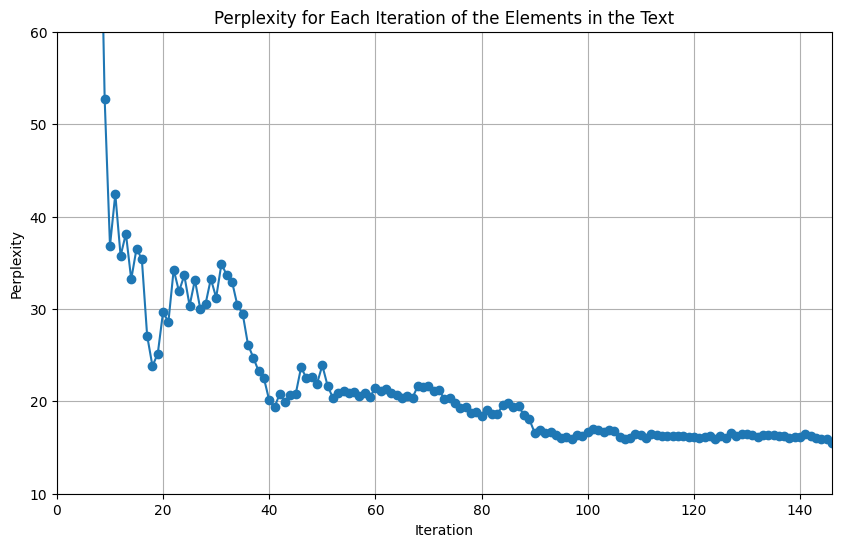

In [31]:
input_text = "Bees are essential pollinators that play a critical role in ecosystems and agriculture worldwide. With over 20,000 species, these industrious insects facilitate the reproduction of flowering plants by transferring pollen, enabling the growth of fruits, vegetables, and seeds. Honeybees, bumblebees, and solitary bees each contribute uniquely to this process. Beyond pollination, honeybees produce honey and beeswax, which have been harvested by humans for centuries. However, bee populations face significant threats from habitat loss, pesticide exposure, and climate change, leading to alarming declines. The phenomenon known as Colony Collapse Disorder (CCD) highlights the urgent need for conservation efforts. Protecting bees involves creating bee-friendly habitats, reducing pesticide use, and supporting organic farming practices. Public awareness and education about bees' importance are crucial in ensuring their survival. Safeguarding bees not only preserves biodiversity but also secures food supplies for future generations, underscoring their invaluable role in the natural world."

import matplotlib.pyplot as plt

# Split the input text into words
words = input_text.split()

# Initialize lists to store the cumulative text and corresponding perplexities
cumulative_texts = []
perplexities = []

# Calculate perplexity for each cumulative text
for i in range(1, len(words) + 1):
    cumulative_text = " ".join(words[:i])
    cumulative_texts.append(cumulative_text)
    perplexity = calculate_perplexity(cumulative_text)
    perplexities.append(perplexity)

# Plot the perplexities
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(words) + 1), perplexities, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Perplexity')
plt.title('Perplexity for Each Iteration of the Elements in the Text')
plt.grid(True)
# Zoom in on iterations 10 to the end
plt.xlim(0, len(words))
plt.ylim(10, 60)
plt.show()


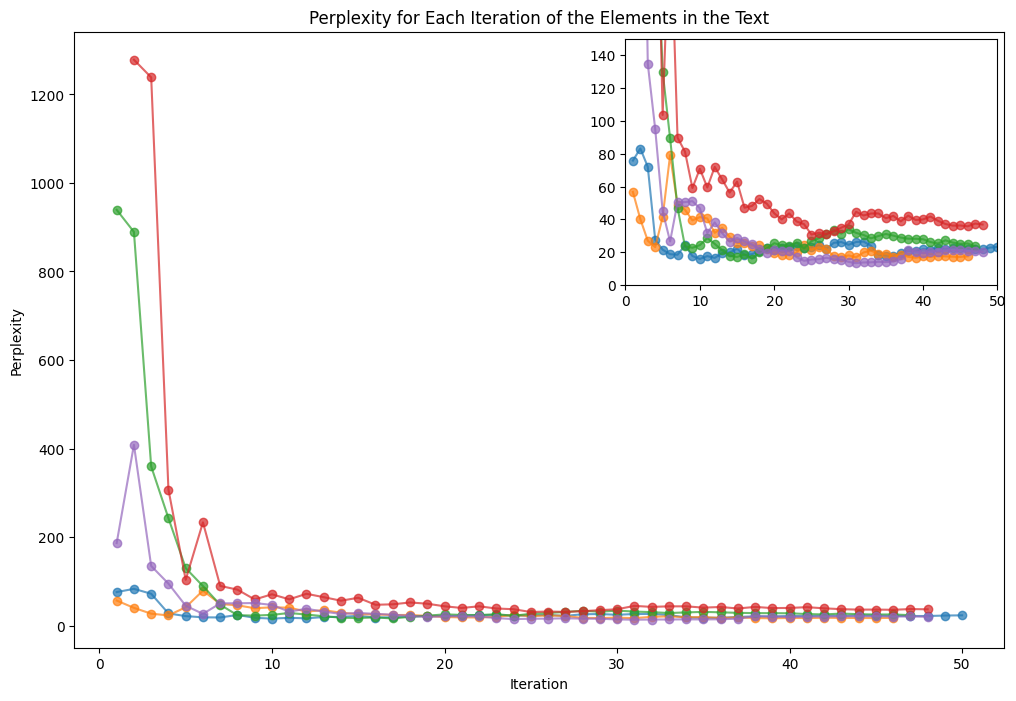

In [32]:
paragraphs = [
    # "Board games have entertained people for thousands of years, with some dating back to ancient Egypt and Mesopotamia. Games like Senet, the Royal Game of Ur, and Go provided both leisure and strategic thinking. They often had cultural, religious, or educational significance, influencing modern games we play today.",
    "Deep-sea creatures like jellyfish, anglerfish, and plankton use bioluminescence to attract prey, communicate, or evade predators. This natural glow is produced through chemical reactions within their bodies. Found mostly in deep, dark waters, bioluminescence is a survival adaptation that continues to fascinate scientists studying marine life and its mysterious ecosystems.",
    # "From fire tornadoes to ball lightning, the planet experiences bizarre weather events. Red sprites flash in the upper atmosphere during thunderstorms, while snow donuts form under rare conditions. These unusual phenomena challenge scientists to better understand Earth’s dynamic climate systems and the strange forces that shape our weather.",
    # "Lost cities spark the imagination, from the legendary Atlantis to the real ruins of Pompeii and Machu Picchu. Some, like Angkor and Petra, were rediscovered after centuries of being hidden by nature. These ancient sites reveal insights into past civilizations, their achievements, and the mysteries of their disappearance.",
    "Procrastination is a common struggle rooted in psychology. It often stems from fear of failure, perfectionism, or a lack of motivation. The brain favors short-term rewards over long-term goals, leading to delays. Overcoming procrastination involves self-discipline, time management, and understanding the emotions that drive the habit.",
    "Musical instruments have evolved over thousands of years, from primitive drums and flutes to modern electronic synthesizers. Ancient civilizations crafted instruments from natural materials, shaping musical traditions. Innovations in design and technology have expanded their range and capabilities, allowing musicians to create increasingly complex and expressive sounds.",
    # "Dreams remain one of psychology’s greatest mysteries. While some theories suggest they help process emotions, others see them as random brain activity. Lucid dreaming, where a person is aware they are dreaming, allows some control over dream events. Studying dreams may offer insights into consciousness and the subconscious mind.",
    # "Uncontacted tribes live in remote regions, untouched by modern civilization. Found in places like the Amazon and Papua New Guinea, they maintain ancient ways of life. However, they face threats from deforestation, disease, and illegal activities. Ethical debates continue on how to respect their isolation while protecting their land.",
    "Space junk, made up of defunct satellites, debris, and rocket fragments, orbits Earth at high speeds. As more satellites launch, the risk of collisions increases. Scientists are developing solutions like nets and laser systems to remove debris, ensuring that space remains safe for future exploration and communication technology.",
    "Fungi play a crucial role in ecosystems by decomposing organic matter, recycling nutrients, and forming symbiotic relationships with plants. Some fungi, like mycorrhizal fungi, help plants absorb nutrients, while others, like mushrooms, provide food and medicine. Understanding fungi’s role in nature can improve agriculture, medicine, and environmental conservation."
]

plt.figure(figsize=(12, 8))

# Loop through each paragraph and plot all graphs in the same figure
for paragraph in paragraphs:
    words = paragraph.split()
    perplexities = [calculate_perplexity(" ".join(words[:i])) for i in range(1, len(words) + 1)]
    plt.plot(range(1, len(words) + 1), perplexities, marker='o', linestyle='-', alpha=0.7)

plt.xlabel('Iteration')
plt.ylabel('Perplexity')
plt.title('Perplexity for Each Iteration of the Elements in the Text')

# Create enlarged inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ax_inset = inset_axes(plt.gca(), width="40%", height="40%", loc='upper right')  # Increased size
for paragraph in paragraphs:
    words = paragraph.split()
    perplexities = [calculate_perplexity(" ".join(words[:i])) for i in range(1, len(words) + 1)]
    ax_inset.plot(range(1, len(words) + 1), perplexities, marker='o', linestyle='-', alpha=0.7)

ax_inset.set_xlim(0, max(len(p.split()) for p in paragraphs))
ax_inset.set_ylim(0, 150)

# Show the final combined plot
plt.show()